In [1]:
import os, glob
import pandas as pd
# from playground_paraphraser import DATASET_MAP
# from playground_consistency_analysis import get_paths
# from math_verify import parse, LatexExtractionConfig, verify
import math_verify

from llm_consistency.datasets.registry import get_dataset_spec
from llm_consistency.core.paths import ProjectPaths



# dataset = "SimpleQA"
# experiment_flag = "with_tones"
# dataset = "gsm8k_test"
dataset = "math_500_test"
# experiment_flag = "with_tones"
experiment_flag = "v00"
temperature = 0.0
question_subset="both"
paths = ProjectPaths()
rp = paths.run_paths(dataset, experiment_flag)
conf = rp.conf_suffix(temperature=temperature)
dataset_cfg = get_dataset_spec(dataset)

dataset_df = pd.read_csv(paths.dataset_file(dataset_cfg["path"]))
qcol = dataset_cfg["question_col"]

df = pd.read_csv(rp.answers_all_models_file("both", conf))
print(df.shape)

(18520, 5)


In [2]:
df.idx.nunique(), dataset_df.shape

(152, (500, 6))

In [3]:
import pandas as pd

MAX_CHARS = 40_000

def add_gold_columns(df, max_chars=MAX_CHARS):
    """Adds gold question & gold answer columns based on df['idx'].
    Skips parsing for overly-long answers (sets answer_parsed=None, correct=False).
    """
    df = df.copy()

    # Gold columns (these are fast; keep as-is)
    df["gold_answer"] = df["idx"].apply(lambda i: dataset_df.iloc[i]["answer"])
    df["gold_answer_parsed"] = df["idx"].apply(
        lambda i: math_verify.parse(f'${dataset_df.iloc[i]["answer"]}$')
    )

    # Length-based skip
    ans_str = df["answer"].fillna("").astype(str)
    df["answer_len"] = ans_str.str.len()
    too_long = df["answer_len"] > max_chars

    # Default outputs for skipped rows
    df["answer_parsed"] = None

    # Parse only the “safe length” subset
    to_parse = ~too_long
    df.loc[to_parse, "answer_parsed"] = ans_str[to_parse].apply(
        lambda ans: math_verify.parse(
            ans,
            fallback_mode="no_fallback",
            extraction_config=[
                math_verify.LatexExtractionConfig(
                    boxed_match_priority=0,
                    try_extract_without_anchor=True,
                ),
            ],
        )
    )

    # Correctness: only verify where we actually parsed an answer
    df["correct"] = False
    df.loc[to_parse, "correct"] = df.loc[to_parse].apply(
        lambda row: math_verify.verify(row["gold_answer_parsed"], row["answer_parsed"]),
        axis=1,
    )

    return df

new_df = add_gold_columns(df, max_chars=32_000)

print("Gold columns added; long answers skipped.")
new_df


Timeout during comparison


Gold columns added; long answers skipped.


,model,idx,original_question,paraphrased_question,answer,gold_answer,gold_answer_parsed,answer_len,answer_parsed,correct
0,gpt-4o,0,"Convert the point $(0,3)$ in rectangular coord...","Convert the point $(0,3)$ in rectangular coord...","To convert the point \((0, 3)\) from rectangul...","\left( 3, \frac{\pi}{2} \right)","[(3, pi/2), ( 3, \frac{\pi}{2} )]",922,"[(3, pi/2)]",True
1,gpt-4o,0,"Convert the point $(0,3)$ in rectangular coord...","Express the point (0,3) from rectangular coord...","To convert the point \((0, 3)\) from rectangul...","\left( 3, \frac{\pi}{2} \right)","[(3, pi/2), ( 3, \frac{\pi}{2} )]",927,"[(3, pi/2)]",True
2,gpt-4o,0,"Convert the point $(0,3)$ in rectangular coord...","Express the point (0,3) from Cartesian form to...","To convert the point \((0, 3)\) from Cartesian...","\left( 3, \frac{\pi}{2} \right)","[(3, pi/2), ( 3, \frac{\pi}{2} )]",873,"[(3, pi/2)]",True
3,gpt-4o,0,"Convert the point $(0,3)$ in rectangular coord...","Express the point (0, 3) given in Cartesian co...","To convert the Cartesian coordinates \((0, 3)\...","\left( 3, \frac{\pi}{2} \right)","[(3, pi/2), ( 3, \frac{\pi}{2} )]",890,"[(3, pi/2)]",True
4,gpt-4o,0,"Convert the point $(0,3)$ in rectangular coord...","How would the point (0,3) be expressed in pola...","To convert the Cartesian coordinates \((x, y)\...","\left( 3, \frac{\pi}{2} \right)","[(3, pi/2), ( 3, \frac{\pi}{2} )]",755,"[(3, pi/2)]",True
...,...,...,...,...,...,...,...,...,...,...
18515,openai/gpt-oss-20b,198,In how many ways can 6 girls and 2 boys sit in...,Could you help me find how many ways 6 girls a...,analysisWe need to count arrangements of 6 gir...,"10,\!080","[10080, 10,080]",1152,[10080],True
18516,openai/gpt-oss-20b,199,"The arithmetic mean of 7, 2, $x$ and 10 is 9. ...","The arithmetic mean of 7, 2, $x$ and 10 is 9. ...",analysisWe need to solve: arithmetic mean of 7...,17,"[17, 17]",641,[17],True
18517,openai/gpt-oss-20b,199,"The arithmetic mean of 7, 2, $x$ and 10 is 9. ...","If the average of 7, 2, x, and 10 equals 9, wh...","analysisWe need to solve: average of 7, 2, x, ...",17,"[17, 17]",858,[17],True
18518,openai/gpt-oss-20b,199,"The arithmetic mean of 7, 2, $x$ and 10 is 9. ...","Given that the arithmetic mean of 7, 2, x, and...",analysisWe need to solve: arithmetic mean of 7...,17,"[17, 17]",817,[17],True


In [4]:
from sympy import sympify, simplify
from sympy.core.relational import Relational, Equality
from sympy.logic.boolalg import BooleanFunction
def extract_numeric_value_(parsed):
    """Return the true numeric value from math_verify.parse output."""
    if not parsed:
        return None
    
    obj = parsed[0]

    # Convert parse node to a string so SymPy can evaluate
    expr_str = str(obj)

    # Reject equations, booleans, etc.
    if isinstance(obj, (Relational)):
        expr = obj
    else:
        try:
            expr = sympify(expr_str)
        except Exception:
            return None

    if isinstance(expr, (Relational, BooleanFunction)):
        # ---- MINIMAL PATCH FOR YOUR FAILURE CASES ----
        try:
            rhs = expr.rhs
            if rhs.is_number:
                expr = expr.rhs
        except:
            pass

    # Normal numeric/aexpr path  
    simplified = simplify(expr)
    # Normalize float→int if possible
    if simplified.is_Integer:
        return int(simplified)
    if simplified.is_Rational:
        return float(simplified) if simplified.q != 1 else int(simplified)
    if simplified.is_Float:
        iv = int(simplified)
        return iv if iv == simplified else float(simplified)

    # Fallback: string of simplified expression
    return str(simplified)

tt = new_df.copy()
tt["ans_norm"]  = tt["answer_parsed"].apply(extract_numeric_value_)
tt["gold_norm"] = tt["gold_answer_parsed"].apply(extract_numeric_value_)
tt["correct_"]  = tt["ans_norm"] == tt["gold_norm"]


In [5]:
len(tt[tt["correct"] != tt["correct_"]]) # this should be zero if we want the entropy on values to make sense

121

In [6]:
new_df = tt.copy()
print(new_df[new_df.answer_parsed.str.len() == 0].shape, new_df.shape)
new_df = new_df[(new_df.answer_parsed.str.len() > 0) & (new_df.answer_parsed != None)]
print(new_df.shape)
new_df = new_df[~new_df.ans_norm.isnull()]
print(new_df.shape)
orig_df = new_df[new_df.original_question == new_df.paraphrased_question].copy()
para_df = new_df[new_df.original_question != new_df.paraphrased_question].copy()
print(orig_df.shape, para_df.shape)

(287, 13) (18520, 13)
(17582, 13)
(17551, 13)
(2888, 13) (14663, 13)


## HERE the actual analysis begins!

In [7]:
def original_distribution(df_orig, col="correct", suffix="_orig"):
    dist = pd.get_dummies(df_orig[col])

    # Rename boolean columns
    if True in dist.columns and False in dist.columns:
        dist = dist.rename(columns={True: "correct", False: "incorrect"})

    # Add suffix
    dist.columns = dist.columns.astype(str) + suffix

    dist["idx"] = df_orig["idx"]
    dist["model"] = df_orig["model"]
    out = dist.set_index(["idx", "model"])

    return out

def paraphrased_distribution(df_para, col="correct", suffix="_para"):
    norm = (
        df_para
        .groupby(["idx", "model"])[col]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
    )

    # Rename boolean columns
    if True in norm.columns and False in norm.columns:
        norm = norm.rename(columns={True: "correct", False: "incorrect"})

    # Add suffix
    norm.columns = norm.columns.astype(str) + suffix

    return norm

import numpy as np
def iid_mismatch_metric(group, col="ans_norm", suffix=""):
    p = group[col].value_counts(normalize=True)
    iid_mismatch_prob = 1 - (p ** 2).sum()
    distinct_answers = p.size
    mode_share = p.max()
    entropy = -(p * np.log(p)).sum()

    res = {
        "iid_mismatch_prob": iid_mismatch_prob,
        "distinct": distinct_answers,
        "mode_share": mode_share,
        "entropy": entropy,
        "num_paraphrases": len(group),
        "normalized_entropy": entropy / np.log(len(group)) if len(group) > 1 else 0.0,
        # just added!
        "maj_value": p.idxmax(),
    }
    # if not suffix:
    #     suffix = f"_{col}"
    res = {k + suffix: v for k, v in res.items()}
    return pd.Series(res)


In [8]:
orig_dist = original_distribution(orig_df, col="correct", suffix="_orig")
para_dist = paraphrased_distribution(para_df, col="correct", suffix="_para")
both_dist = paraphrased_distribution(new_df, col="correct", suffix="_both")
para_dist2 = para_df.groupby(["idx", "model"])[["correct"]].apply(iid_mismatch_metric, col="correct", suffix="_correct_para")
para_dist3 = para_df.groupby(["idx", "model"])[["ans_norm"]].apply(iid_mismatch_metric, col="ans_norm", suffix="_ans_norm_para")
both_dist2 = new_df.groupby(["idx", "model"])[["correct"]].apply(iid_mismatch_metric, col="correct", suffix="_correct_both")
both_dist3 = new_df.groupby(["idx", "model"])[["ans_norm"]].apply(iid_mismatch_metric, col="ans_norm", suffix="_ans_norm_both")
orig_values = orig_df[["idx", "model", "ans_norm"]].rename(columns={"ans_norm": "orig_value"}).set_index(["idx", "model"])
merged = (
    orig_dist
    .join(orig_values, how="inner")
    .join(para_dist, how="inner")
    .join(para_dist2, how="inner")
    .join(para_dist3, how="inner")
    .join(both_dist, how="inner")
    .join(both_dist2, how="inner")
    .join(both_dist3, how="inner")
)
aligned = merged.copy()
# for suffix in ["orig", "para", "both"]:
#     cols = [f"{c}_{suffix}" for c in ["correct", "incorrect"]]
#     aligned[f"{suffix}_label"] = aligned[cols].idxmax(axis=1).str.replace(f"_{suffix}", "")
#     # cols = [f"{c}_{suffix}" for c in ["correct", "incorrect"]]
#     # aligned[f"{suffix}_label"] = df[cols].idxmax(axis=1).str.replace(f"_{suffix}", "")

for subset in ["orig", "para", "both"]:
    labels = ["correct_", "incorrect_"]
    cols = [label + subset for label in labels]

    aligned[f"{subset}_label"] = merged[cols].idxmax(axis=1).str.replace(f"_{subset}", "")
    vals = merged[cols]

    row_max = vals.max(axis=1)
    num_max = vals.eq(row_max, axis=0).sum(axis=1)

    # aligned[f"{subset}_label"] = np.where(
    #     num_max == 1,
    #     vals.idxmax(axis=1).str.replace(f"_{subset}", ""),
    #     "tie"
    # )

    aligned[f"{subset}_is_tie"] = num_max > 1
    def tied_labels(row):
        m = row.max()
        return tuple(
            c.replace(f"_{subset}", "")
            for c in cols if row[c] == m
        )

    aligned[f"{subset}_tied_labels"] = merged[cols].apply(tied_labels, axis=1)
aligned["match"] = aligned["orig_label"] == aligned["para_label"]
aligned["match_value"] = aligned["orig_value"] == aligned["maj_value_ans_norm_para"]
aligned["match_"] = aligned["orig_label"] == aligned["both_label"]
with pd.option_context(
    'display.max_colwidth', None,
    'display.max_columns', None,
    'display.expand_frame_repr', False
):
    display(
        aligned[~aligned.correct_orig]
    )
aligned.shape

,,incorrect_orig,correct_orig,orig_value,incorrect_para,correct_para,iid_mismatch_prob_correct_para,distinct_correct_para,mode_share_correct_para,entropy_correct_para,num_paraphrases_correct_para,normalized_entropy_correct_para,maj_value_correct_para,iid_mismatch_prob_ans_norm_para,distinct_ans_norm_para,mode_share_ans_norm_para,entropy_ans_norm_para,num_paraphrases_ans_norm_para,normalized_entropy_ans_norm_para,maj_value_ans_norm_para,incorrect_both,correct_both,iid_mismatch_prob_correct_both,distinct_correct_both,mode_share_correct_both,entropy_correct_both,num_paraphrases_correct_both,normalized_entropy_correct_both,maj_value_correct_both,iid_mismatch_prob_ans_norm_both,distinct_ans_norm_both,mode_share_ans_norm_both,entropy_ans_norm_both,num_paraphrases_ans_norm_both,normalized_entropy_ans_norm_both,maj_value_ans_norm_both,orig_label,orig_is_tie,orig_tied_labels,para_label,para_is_tie,para_tied_labels,both_label,both_is_tie,both_tied_labels,match,match_value,match_
idx,model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
9,gpt-4o,True,False,2,0.800000,0.200000,0.320000,2,0.800000,0.500402,5,0.310918,False,0.640000,3.0,0.400000,1.054920,5.0,0.655459,2.0,0.833333,0.166667,0.277778,2,0.833333,0.450561,6,0.251463,False,0.611111,3.0,0.500000,1.011404,6.0,0.564475,2.0,incorrect,False,"(incorrect,)",incorrect,False,"(incorrect,)",incorrect,False,"(incorrect,)",True,True,True
11,gpt-4o,True,False,11.555556,1.000000,0.000000,0.000000,1,1.000000,-0.000000,3,-0.000000,False,0.444444,2.0,0.666667,0.636514,3.0,0.579380,0.126984,1.000000,0.000000,0.000000,1,1.000000,-0.000000,4,-0.000000,False,0.500000,2.0,0.500000,0.693147,4.0,0.500000,11.555556,incorrect,False,"(incorrect,)",incorrect,False,"(incorrect,)",incorrect,False,"(incorrect,)",True,False,True
21,gpt-4o,True,False,13500,1.000000,0.000000,0.000000,1,1.000000,-0.000000,5,-0.000000,False,0.720000,4.0,0.400000,1.332179,5.0,0.827729,13823.0,1.000000,0.000000,0.000000,1,1.000000,-0.000000,6,-0.000000,False,0.777778,5.0,0.333333,1.560710,6.0,0.871049,13823.0,incorrect,False,"(incorrect,)",incorrect,False,"(incorrect,)",incorrect,False,"(incorrect,)",True,False,True
25,gpt-4o,True,False,"{-1, 1}",1.000000,0.000000,0.000000,1,1.000000,-0.000000,2,-0.000000,False,0.500000,2.0,0.500000,0.693147,2.0,1.000000,"{-1, 1}",1.000000,0.000000,0.000000,1,1.000000,-0.000000,3,-0.000000,False,0.444444,2.0,0.666667,0.636514,3.0,0.579380,"{-1, 1}",incorrect,False,"(incorrect,)",incorrect,False,"(incorrect,)",incorrect,False,"(incorrect,)",True,True,True
43,gpt-4o,True,False,60,1.000000,0.000000,0.000000,1,1.000000,-0.000000,1,0.000000,False,0.000000,1.0,1.000000,-0.000000,1.0,0.000000,92.0,1.000000,0.000000,0.000000,1,1.000000,-0.000000,2,-0.000000,False,0.500000,2.0,0.500000,0.693147,2.0,1.000000,60.0,incorrect,False,"(incorrect,)",incorrect,False,"(incorrect,)",incorrect,False,"(incorrect,)",True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,openai/gpt-oss-20b,True,False,0.111111,0.000000,1.000000,0.000000,1,1.000000,-0.000000,2,-0.000000,True,0.000000,1.0,1.000000,-0.000000,2.0,-0.000000,0.053571,0.333333,0.666667,0.444444,2,0.666667,0.636514,3,0.579380,True,0.444444,2.0,0.666667,0.636514,3.0,0.579380,0.053571,incorrect,False,"(incorrect,)",correct,False,"(correct,)",correct,False,"(correct,)",False,False,False
43,openai/gpt-oss-20b,True,False,"{b**2, -a*b}",1.000000,0.000000,0.000000,1,1.000000,-0.000000,1,0.000000,False,0.000000,1.0,1.000000,-0.000000,1.0,0.000000,10*(7*v - 410)/(v - 70),1.000000,0.000000,0.000000,1,1.000000,-0.000000,2,-0.000000,False,0.500000,2.0,0.500000,0.693147,2.0,1.000000,"{b**2, -a*b}",incorrect,False,"(incorrect,)",incorrect,False,"(incorrect,)",incorrect,False,"(incorrect,)",True,False,True
67,openai/gpt-oss-20b,True,False,0.1,1.000000,0.000000,0.000000,1,1.000000,-0.000000,8,-0.000000,False,0.000000,1.0,1.0

(2869, 47)

### Results Generation (Load OR Save previous analysis!)

In [9]:
import pandas as pd
dataset = "math_500_test"
intermediate_path = f"aligned_verdicts_{dataset}.pkl"
# Save
# aligned.reset_index().to_pickle(intermediate_path)

# Load
atemp = pd.read_pickle(intermediate_path)
aligned = atemp.set_index(['idx', 'model'])

# Now they'll match perfectly
atemp.equals(aligned.reset_index())  # True

True

In [10]:
tie_stats = {}

for subset in ["orig", "para", "both"]:
    labels = ["correct_", "incorrect_"]
    cols = [label + subset for label in labels]

    row_max = aligned[cols].max(axis=1)
    num_max = aligned[cols].eq(row_max, axis=0).sum(axis=1)

    tie_stats[subset] = {
        "num_rows": len(aligned),
        "num_ties": (num_max > 1).sum(),
        "tie_rate": (num_max > 1).mean(),
    }

tie_stats


{'orig': {'num_rows': 2869,
  'num_ties': np.int64(0),
  'tie_rate': np.float64(0.0)},
 'para': {'num_rows': 2869,
  'num_ties': np.int64(117),
  'tie_rate': np.float64(0.04078075984663646)},
 'both': {'num_rows': 2869,
  'num_ties': np.int64(70),
  'tie_rate': np.float64(0.024398745207389334)}}

In [11]:
aligned_prev = aligned.copy()
print(aligned_prev.shape)
aligned = aligned[(~aligned["para_is_tie"]) & (~aligned["orig_is_tie"])]
print(aligned.shape)
# aligned = aligned_prev
# print(aligned.shape)

(2869, 47)
(2752, 47)


In [12]:
from analysis_utils import df_to_acl_icml_table, prep_for_paper, prep, model_name_map

import re
import pandas as pd

def sort_with_my_logic(df: pd.DataFrame, model_col: str = "model", score_col="correct_orig") -> pd.DataFrame:
    df = df.reset_index(drop=True).copy()

    s = df[model_col].astype(str)

    # ---- parse "size" like 0.6B / 1.7B / 7B / 20b ----
    # returns float billions, NaN if missing
    def parse_size_b(name: str):
        m = re.search(r"(\d+(?:\.\d+)?)\s*[Bb]\b", name)
        return float(m.group(1)) if m else float("nan")

    size_b = s.map(parse_size_b)

    # ---- family ordering (customize this order if you want) ----
    # Lower number = earlier in table
    def family_rank(name: str) -> int:
        n = name.lower()
        if n.startswith("gpt-") or n.startswith("openai/"):
            return 0
        if "llama" in n:
            return 1
        if "qwen" in n:
            return 2
        return 9  # unknown/other

    fam = s.map(family_rank)

    # ---- version keys within a family (so Qwen2.5 before Qwen3, LLaMA3 before 3.1, etc.) ----
    def qwen_version(name: str):
        m = re.search(r"Qwen(?:/Qwen)?(\d+(?:\.\d+)?)", name)
        return float(m.group(1)) if m else float("inf")

    def llama_version(name: str):
        m = re.search(r"Llama-?(\d+(?:\.\d+)?)", name, flags=re.IGNORECASE)
        return float(m.group(1)) if m else float("inf")

    qwen_v = s.map(lambda x: qwen_version(x) if "qwen" in x.lower() else float("inf"))
    llama_v = s.map(lambda x: llama_version(x) if "llama" in x.lower() else float("inf"))

    # One "version" column that matters per family
    version = pd.Series(float("inf"), index=df.index)
    version = version.mask(s.str.contains("qwen", case=False, na=False), qwen_v)
    version = version.mask(s.str.contains("llama", case=False, na=False), llama_v)

    # ---- thinking flag (doesn't matter; keep as final stable tie-breaker) ----
    thinking = s.str.contains(r"\[with_thinking\]", na=False)

    # ---- normalize name for stable tie-break (remove vendor prefixes, optional) ----
    # (keeps sort deterministic for equal keys)
    base = (
        s.str.replace(r"^(meta-llama/|Qwen/|openai/)", "", regex=True)
         .str.replace(r"\[with_thinking\]$", "", regex=True)
    )

    df = df.assign(_fam=fam, _ver=version, _size=size_b, _base=base, _thinking=thinking)

    return (
        df.sort_values(["_fam", "_ver", "_size", "_base", "_thinking"], ascending=[True, True, True, True, True])
          .drop(columns=["_fam", "_ver", "_size", "_base", "_thinking"])
          .reset_index(drop=True)
    )


In [13]:
dist_cols = ["correct_orig","incorrect_orig","correct_para","incorrect_para"]

dist = aligned.groupby("model")[dist_cols].mean()
diff_df = aligned.assign(
    correct_diff = aligned["correct_para"] - aligned["correct_orig"].astype(float),
    incorrect_diff = aligned["incorrect_para"] - aligned["incorrect_orig"].astype(float),
).groupby("model")[["correct_diff", "incorrect_diff"]].mean()
total_counts = aligned.groupby("model").size().rename("N")
agg_dist = dist.join(diff_df).join(total_counts)
agg_dist.sort_values("correct_orig", ascending=False).round(2)

,correct_orig,incorrect_orig,correct_para,incorrect_para,correct_diff,incorrect_diff,N
model,,,,,,,
Qwen/Qwen3-8B[with_thinking],1.00,0.00,0.97,0.03,-0.03,0.03,137
Qwen/Qwen3-32B[with_thinking],1.00,0.00,0.97,0.03,-0.03,0.03,141
Qwen/Qwen3-14B[with_thinking],0.99,0.01,0.97,0.03,-0.02,0.02,137
Qwen/Qwen3-4B[with_thinking],0.99,0.01,0.97,0.03,-0.02,0.02,135
Qwen/Qwen3-1.7B[with_thinking],0.98,0.02,0.96,0.04,-0.03,0.03,127
openai/gpt-oss-20b,0.96,0.04,0.93,0.07,-0.04,0.04,135
gpt-4.1-mini,0.96,0.04,0.91,0.09,-0.04,0.04,146
Qwen/Qwen3-14B,0.94,0.06,0.89,0.11,-0.05,0.05,143
gpt-4.1,0.94,0.06,0.90,0.10,-0.04,0.04,143


In [14]:
# Original label frequencies
orig_dist = (
    aligned.groupby("model")["orig_label"]
    .value_counts(normalize=True)
    .unstack().fillna(0)
    # .add_prefix("orig_")
)

# Paraphrased label frequencies
para_dist = (
    aligned.groupby("model")["para_label"]
    .value_counts(normalize=True)
    .unstack().fillna(0)
    # .add_prefix("para_")
)

# Differences
label_diff = (para_dist - orig_dist)
orig_dist = orig_dist.add_suffix("_orig")
para_dist = para_dist.add_suffix("_maj_vote")
label_diff = label_diff.add_suffix("_diff")

total_counts = aligned.groupby("model").size().rename("total_samples")

agg_maj = (
    # dist
    # .join(diff_df)
    # .join()
        orig_dist
    .join(para_dist)
    .join(label_diff)
    .join(total_counts)
)

agg_maj.sort_values("correct_orig", ascending=False).round(2)


,correct_orig,incorrect_orig,correct_maj_vote,incorrect_maj_vote,correct_diff,incorrect_diff,total_samples
model,,,,,,,
Qwen/Qwen3-8B[with_thinking],1.00,0.00,0.98,0.02,-0.02,0.02,137
Qwen/Qwen3-32B[with_thinking],1.00,0.00,0.98,0.02,-0.02,0.02,141
Qwen/Qwen3-14B[with_thinking],0.99,0.01,0.98,0.02,-0.01,0.01,137
Qwen/Qwen3-4B[with_thinking],0.99,0.01,0.98,0.02,-0.01,0.01,135
Qwen/Qwen3-1.7B[with_thinking],0.98,0.02,0.97,0.03,-0.02,0.02,127
openai/gpt-oss-20b,0.96,0.04,0.93,0.07,-0.03,0.03,135
gpt-4.1-mini,0.96,0.04,0.93,0.07,-0.03,0.03,146
Qwen/Qwen3-14B,0.94,0.06,0.90,0.10,-0.04,0.04,143
gpt-4.1,0.94,0.06,0.91,0.09,-0.03,0.03,143


In [15]:
merged_ = (
    agg_dist[["correct_orig", "correct_para", "correct_diff", "N"]]
    .join(
        agg_maj[["correct_orig", "correct_maj_vote", "correct_diff"]],
        how="inner",
        lsuffix="_dist",
        rsuffix="_mv"
    )
)
merged_.round(2)

,correct_orig_dist,correct_para,correct_diff_dist,N,correct_orig_mv,correct_maj_vote,correct_diff_mv
model,,,,,,,
Qwen/Qwen2.5-7B-Instruct,0.75,0.72,-0.03,144,0.75,0.74,-0.01
Qwen/Qwen3-0.6B,0.59,0.55,-0.03,129,0.59,0.54,-0.05
Qwen/Qwen3-0.6B[with_thinking],0.90,0.87,-0.04,113,0.90,0.88,-0.03
Qwen/Qwen3-1.7B,0.81,0.73,-0.07,135,0.81,0.76,-0.04
Qwen/Qwen3-1.7B[with_thinking],0.98,0.96,-0.03,127,0.98,0.97,-0.02
Qwen/Qwen3-14B,0.94,0.89,-0.05,143,0.94,0.90,-0.04
Qwen/Qwen3-14B[with_thinking],0.99,0.97,-0.02,137,0.99,0.98,-0.01
Qwen/Qwen3-32B,0.92,0.88,-0.05,146,0.92,0.90,-0.02
Qwen/Qwen3-32B[with_thinking],1.00,0.97,-0.03,141,1.00,0.98,-0.02


In [16]:
# Drop duplicate orig correctness (dist and mv should match up to rounding)
merged = merged_.drop(columns=["correct_orig_mv"])
merged = merged.rename(columns={
    "correct_orig_dist": "Orig Acc",
    "correct_para": "Para Acc (Dist)",
    "correct_maj_vote": "Para Acc (MV)",
    "correct_diff_dist": r"$\Delta$Acc (Dist)",
    "correct_diff_mv": r"$\Delta$Acc (MV)"
})

merged = merged.sort_values("Orig Acc", ascending=False).reset_index()

order_cols = [
    "model",
    "Orig Acc",
    "Para Acc (MV)",
    r"$\Delta$Acc (MV)",
    "Para Acc (Dist)",
    r"$\Delta$Acc (Dist)",
    "N"
]

merged = merged[order_cols]

merged = sort_with_my_logic(merged, score_col="Orig Acc", model_col="model")

merged = prep(merged)   # format percentages etc.
latex_gsm_merged = df_to_acl_icml_table(
    df=merged,
    caption="Original and paraphrased correctness under majority-vote and distributional scoring (MATH-500).",
    label="math-500-correctness-combined",
    short_model_names=model_name_map,
    col_format="l" + "c"*(merged.shape[1]-1),
    full_width=True,
    bold_negative_cols=["$\Delta$Acc (MV)", "$\Delta$Acc (Dist)"],
    color_negative_cols=["$\Delta$Acc (MV)", "$\Delta$Acc (Dist)"],
)
print(latex_gsm_merged)


\begin{table*}[t]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccc}
\toprule
model & Orig Acc & Para Acc (MV) & $\Delta$Acc (MV) & Para Acc (Dist) & $\Delta$Acc (Dist) & N \\
\midrule
GPT-OSS 20B & 96.3 & 93.3 & \textcolor{red}{\textbf{-3.0}} & 92.6 & \textcolor{red}{\textbf{-3.7}} & 135 \\
GPT-3.5 & 44.8 & 42.8 & \textcolor{red}{\textbf{-2.1}} & 43.3 & \textcolor{red}{\textbf{-1.6}} & 145 \\
GPT-4.1 & 94.4 & 90.9 & \textcolor{red}{\textbf{-3.5}} & 90.5 & \textcolor{red}{\textbf{-3.9}} & 143 \\
GPT-4.1-Mini & 95.9 & 93.2 & \textcolor{red}{\textbf{-2.7}} & 91.5 & \textcolor{red}{\textbf{-4.4}} & 146 \\
GPT-4o & 79.2 & 79.2 & 0.0 & 78.3 & \textcolor{red}{\textbf{-0.9}} & 144 \\
LLaMA-3 8B & 30.0 & 26.4 & \textcolor{red}{\textbf{-3.6}} & 26.6 & \textcolor{red}{\textbf{-3.4}} & 140 \\
LLaMA-3.1 8B & 49.2 & 53.0 & 3.8 & 52.4 & 3.2 & 132 \\
Qwen-2.5 7B & 75.0 & 74.3 & \textcolor{red}{\textbf{-0.7}} & 71.5 & \textcolor{red}{\textbf{-3.5}} & 144 \\
Qwen-3 0.6B & 58.9 & 54.3 & \te

In [17]:
merged.reset_index().columns

Index(['index', 'model', 'Orig Acc', 'Para Acc (MV)', '$\Delta$Acc (MV)',
       'Para Acc (Dist)', '$\Delta$Acc (Dist)', 'N'],
      dtype='object')

In [18]:
mismatch_stats = (
    aligned
    .assign(mismatch = ~aligned["match"])
    .groupby("model")
    .agg(
        total_samples = ("match", "size"),
        num_mismatches = ("mismatch", "sum"),
        mismatch_rate = ("mismatch", "mean"),
        iid_mismatch_prob = ("iid_mismatch_prob_correct_para", "mean"),
        normalized_entropy = ("normalized_entropy_correct_para", "mean"),
        iid_mismatch_ans_norm_prob = ("iid_mismatch_prob_ans_norm_para", "mean"),
        normalized_entropy_ans_norm = ("normalized_entropy_ans_norm_para", "mean"),
        mode_share = ("mode_share_correct_para", "mean"),
        mode_share_ans_norm = ("mode_share_ans_norm_para", "mean"),
    )
)
mismatch_stats.sort_values('mismatch_rate', ascending=False).round(2)
gsm_merged = (
    agg_dist[["correct_orig", "correct_para", "correct_diff", "N"]]
    .join(mismatch_stats, how="inner")
    .sort_values("correct_orig", ascending=False)
)
gsm_merged.round(2)

,correct_orig,correct_para,correct_diff,N,total_samples,num_mismatches,mismatch_rate,iid_mismatch_prob,normalized_entropy,iid_mismatch_ans_norm_prob,normalized_entropy_ans_norm,mode_share,mode_share_ans_norm
model,,,,,,,,,,,,,
Qwen/Qwen3-8B[with_thinking],1.00,0.97,-0.03,137,137,3,0.02,0.01,0.01,0.02,0.03,0.99,0.98
Qwen/Qwen3-32B[with_thinking],1.00,0.97,-0.03,141,141,3,0.02,0.01,0.01,0.02,0.03,0.99,0.98
Qwen/Qwen3-14B[with_thinking],0.99,0.97,-0.02,137,137,4,0.03,0.01,0.01,0.03,0.03,0.99,0.98
Qwen/Qwen3-4B[with_thinking],0.99,0.97,-0.02,135,135,4,0.03,0.01,0.01,0.02,0.02,0.99,0.99
Qwen/Qwen3-1.7B[with_thinking],0.98,0.96,-0.03,127,127,2,0.02,0.02,0.02,0.03,0.02,0.98,0.98
openai/gpt-oss-20b,0.96,0.93,-0.04,135,135,6,0.04,0.03,0.03,0.04,0.05,0.98,0.97
gpt-4.1-mini,0.96,0.91,-0.04,146,146,6,0.04,0.03,0.03,0.06,0.06,0.98,0.95
Qwen/Qwen3-14B,0.94,0.89,-0.05,143,143,8,0.06,0.03,0.03,0.06,0.07,0.98,0.95
gpt-4.1,0.94,0.90,-0.04,143,143,7,0.05,0.03,0.03,0.05,0.05,0.98,0.96


In [19]:
gsm_core = (
    aligned
    .assign(mismatch = ~aligned["match"])
    .groupby("model")
    .agg(
        N = ("match", "size"),
        mismatch_rate = ("mismatch", "mean"),
        iid_mismatch_correct = ("iid_mismatch_prob_correct_para", "mean"),
        entropy_correct = ("normalized_entropy_correct_para", "mean"),
        mode_share_correct = ("mode_share_correct_para", "mean"),
    )
)

gsm_core = gsm_core.join(agg_dist[["correct_orig", "correct_para", "correct_diff"]], how='inner')

gsm_core = gsm_core[
    ["correct_orig", "correct_para", 
     "correct_diff",
     "mismatch_rate", "iid_mismatch_correct",
     "entropy_correct", "mode_share_correct",
     "N"]
]
df1 = gsm_core.copy()
gsm_core = gsm_core.reset_index()

rename_core = {
    "correct_orig": "Orig Acc",
    "correct_para": "Para Acc",
    "correct_diff": r"$\Delta$Acc",
    "mismatch_rate": "Mismatch (\%)",
    "iid_mismatch_correct": "IID-Mismatch",
    "entropy_correct": "Entropy",
    "mode_share_correct": "Mode Share (\%)",
}

gsm_core = sort_with_my_logic(gsm_core, score_col="correct_orig", model_col="model")
gsm_core = prep_for_paper(gsm_core, rename_map=rename_core)#.sort_values("Orig Acc", ascending=False)
gsm_core = prep(gsm_core, ignore_pct_col_pats=['iid', 'entropy'])

latex_gsm_core = df_to_acl_icml_table(
    df = gsm_core,
    caption = (
        "Accuracy degradation, mismatch rates, and entropy-based stability "
        "under paraphrasing (MATH-500). "
    ),
    label = "math-500-acc-mismatch",
    short_model_names = model_name_map,  # if you use the same mapping
    col_format = "l" + "c"*(gsm_core.shape[1]-1),
    full_width = True,
    max_header_len = 80,
    custom_float_format=True,
    bold_negative_cols=["$\Delta$Acc"],
    color_negative_cols=["$\Delta$Acc"],
    bold_cells = lambda df: (
        # Start with a False mask of the same shape
        pd.DataFrame(False, index=df.index, columns=df.columns)
        .assign(
            **{
                "Mismatch (\%)": pd.to_numeric(df["Mismatch (\%)"], errors="coerce") >= 10,
                "Entropy": pd.to_numeric(df["Entropy"], errors="coerce") >= 0.1,
                "IID-Mismatch": pd.to_numeric(df["IID-Mismatch"], errors="coerce") >= 0.1,
            }
        )
    ),
)
print(latex_gsm_core)


\begin{table*}[t]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccccc}
\toprule
model & Orig Acc & Para Acc & $\Delta$Acc & Mismatch (\%) & IID-Mismatch & Entropy & Mode Share (\%) & N \\
\midrule
GPT-OSS 20B & 96.3 & 92.6 & \textcolor{red}{\textbf{-3.7}} & 4.4 & 0.03 & 0.03 & 98.3 & 135 \\
GPT-3.5 & 44.8 & 43.3 & \textcolor{red}{\textbf{-1.6}} & \textbf{17.2} & \textbf{0.13} & \textbf{0.11} & 91.1 & 145 \\
GPT-4.1 & 94.4 & 90.5 & \textcolor{red}{\textbf{-3.9}} & 4.9 & 0.03 & 0.03 & 97.6 & 143 \\
GPT-4.1-Mini & 95.9 & 91.5 & \textcolor{red}{\textbf{-4.4}} & 4.1 & 0.03 & 0.03 & 97.6 & 146 \\
GPT-4o & 79.2 & 78.3 & \textcolor{red}{\textbf{-0.9}} & 9.7 & 0.05 & 0.04 & 96.2 & 144 \\
LLaMA-3 8B & 30.0 & 26.6 & \textcolor{red}{\textbf{-3.4}} & \textbf{12.1} & \textbf{0.11} & \textbf{0.1} & 91.7 & 140 \\
LLaMA-3.1 8B & 49.2 & 52.4 & 3.2 & \textbf{22.0} & \textbf{0.15} & \textbf{0.14} & 89.4 & 132 \\
Qwen-2.5 7B & 75.0 & 71.5 & \textcolor{red}{\textbf{-3.5}} & 7.6 & 0.08 & 0.06 & 

In [20]:
gsm_ansnorm = (
    aligned.groupby("model")
    .agg(
        iid_mismatch_ans_norm = ("iid_mismatch_prob_ans_norm_para", "mean"),
        entropy_ans_norm = ("normalized_entropy_ans_norm_para", "mean"),
        mode_share_ans_norm = ("mode_share_ans_norm_para", "mean"),
        N = ("match", "size")
    )
    # .reset_index()
)
gsm_ansnorm = gsm_ansnorm.join(agg_dist[["correct_orig", "correct_para", "correct_diff"]], how='inner').sort_values("correct_orig", ascending=False)
gsm_ansnorm = gsm_ansnorm[
    ["correct_orig", "correct_para", 
     "correct_diff", #"mismatch_rate", 
     "iid_mismatch_ans_norm",
     "entropy_ans_norm", "mode_share_ans_norm",
     "N"]
]
df2 = gsm_ansnorm.copy()
gsm_ansnorm = gsm_ansnorm.reset_index()


In [21]:
rename_ansnorm = {
    "correct_orig": "Orig Acc",
    "correct_para": "Para Acc",
    "correct_diff": r"$\Delta$Acc",
    "iid_mismatch_ans_norm": r"IID-Mismatch (Value)",
    "entropy_ans_norm": r"Entropy (Value)",
    "mode_share_ans_norm": r"Mode Share (Value)",
    "N": "N",
}
# --- Prepare and rename ---

gsm_ansnorm_prepped = sort_with_my_logic(gsm_ansnorm, score_col="correct_orig", model_col="model")
gsm_ansnorm_prepped = prep_for_paper(
    gsm_ansnorm_prepped,
    rename_map={},#rename_ansnorm
)

gsm_ansnorm_prepped = prep(
    gsm_ansnorm_prepped,
    ignore_pct_col_pats=['iid', 'entropy']  # so entropy isn't treated as %
)

# --- LaTeX Table ---
latex_ansnorm = df_to_acl_icml_table(
    df=gsm_ansnorm_prepped,
    # caption=(
    #     "Answer-level variability under paraphrasing (GSM8K). "
    #     "We measure inconsistency in the \\emph{numerical values} produced "
    #     "across paraphrases, using IID-mismatch probability, normalized entropy, "
    #     "and mode share over distinct answer values. These metrics reveal "
    #     "variability that remains hidden when considering only correctness."
    # ),
    caption=(
        """Value-level variability under paraphrasing (MATH-500). 
We report how often paraphrased variants produce \emph{different numerical values} even when their correctness labels agree. 
These metrics quantify stochastic variation that is invisible to binary correctness measures, revealing instability in the model’s underlying reasoning rather than just its accuracy."""
    ),
    label="math-500-anslevel-variability",
    short_model_names=model_name_map,
    col_format="l" + "c"*(gsm_ansnorm_prepped.shape[1]-1),
    full_width=True,
    max_header_len=80,
    custom_float_format=True,
    bold_negative_cols=["correct_diff"],
    color_negative_cols=["correct_diff"],
    bold_cells = lambda df: (
        # Start with a False mask of the same shape
        pd.DataFrame(False, index=df.index, columns=df.columns)
        .assign(
            **{
                "entropy_ans_norm": pd.to_numeric(df["entropy_ans_norm"], errors="coerce") >= 0.1,
                "iid_mismatch_ans_norm": pd.to_numeric(df["iid_mismatch_ans_norm"], errors="coerce") >= 0.1,
            }
        )
    ),
    column_rename_map=rename_ansnorm,
)

print(latex_ansnorm)



\begin{table*}[t]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lccccccc}
\toprule
model & Orig Acc & Para Acc & $\Delta$Acc & IID-Mismatch (Value) & Entropy (Value) & Mode Share (Value) & N \\
\midrule
GPT-OSS 20B & 96.3 & 92.6 & \textcolor{red}{\textbf{-3.7}} & 0.04 & 0.05 & 97.0 & 135 \\
GPT-3.5 & 44.8 & 43.3 & \textcolor{red}{\textbf{-1.6}} & \textbf{0.35} & \textbf{0.42} & 69.3 & 145 \\
GPT-4.1 & 94.4 & 90.5 & \textcolor{red}{\textbf{-3.9}} & 0.05 & 0.05 & 96.2 & 143 \\
GPT-4.1-Mini & 95.9 & 91.5 & \textcolor{red}{\textbf{-4.4}} & 0.06 & 0.06 & 95.2 & 146 \\
GPT-4o & 79.2 & 78.3 & \textcolor{red}{\textbf{-0.9}} & \textbf{0.12} & \textbf{0.13} & 90.5 & 144 \\
LLaMA-3 8B & 30.0 & 26.6 & \textcolor{red}{\textbf{-3.4}} & \textbf{0.45} & \textbf{0.56} & 60.0 & 140 \\
LLaMA-3.1 8B & 49.2 & 52.4 & 3.2 & \textbf{0.3} & \textbf{0.38} & 74.0 & 132 \\
Qwen-2.5 7B & 75.0 & 71.5 & \textcolor{red}{\textbf{-3.5}} & \textbf{0.17} & \textbf{0.19} & 86.8 & 144 \\
Qwen-3 0.6B & 58.9 & 55.4 

In [22]:
mismatch_stats = (
    aligned
    .assign(mismatch = ~aligned["match"])
    .groupby("model")
    .agg(
        # N = ("match", "size"),
        iid_mismatch_correct = ("iid_mismatch_prob_correct_para", "mean"),
        entropy_correct = ("normalized_entropy_correct_para", "mean"),
        iid_mismatch_ans_norm = ("iid_mismatch_prob_ans_norm_para", "mean"),
        entropy_ans_norm = ("normalized_entropy_ans_norm_para", "mean"),
        
    )
)
gsm_merged = (
    agg_dist[["correct_orig", "correct_para", "correct_diff", "N"]]
    .join(mismatch_stats, how="inner")
    .sort_values("correct_orig", ascending=False)
)
order_cols = [
    "correct_orig", "correct_para", "correct_diff",
    "iid_mismatch_correct", "entropy_correct",
    "iid_mismatch_ans_norm", "entropy_ans_norm",
    # "N"
]
gsm_merged = gsm_merged[order_cols]

In [23]:
rename_gsm_variability = {
    "correct_orig": "Orig Acc",
    "correct_para": "Para Acc",
    "correct_diff": r"$\Delta$Acc",
    "iid_mismatch_correct": "IID-Mismatch (Correctness)",
    "entropy_correct": "Entropy (Correctness)",
    "iid_mismatch_ans_norm": "IID-Mismatch (Value)",
    "entropy_ans_norm": "Entropy (Value)",
    "N": "N",
}
# --- Prepare and rename ---

gsm_merged_prepped = sort_with_my_logic(gsm_merged.reset_index(), score_col="correct_orig", model_col="model")
gsm_merged_prepped = prep_for_paper(
    gsm_merged_prepped,
    rename_map={},#rename_ansnorm
)

gsm_merged_prepped = prep(
    gsm_merged_prepped,
    ignore_pct_col_pats=['iid', 'entropy']  # so entropy isn't treated as %
)

# --- LaTeX Table ---
latex_merged = df_to_acl_icml_table(
    df=gsm_merged_prepped,
    caption=(
        r"Correctness- and value-level variability under paraphrasing (MATH-500). "
        r"We report accuracy shifts alongside inconsistency metrics computed at two levels: "
        r"\emph{correctness variability}, which reflects whether paraphrases change the final correctness label, "
        r"and \emph{value variability}, which captures changes in the actual numerical answers even when correctness agrees. "
        r"Together, these metrics reveal reasoning-level instability that binary accuracy alone fails to capture."
    ),
    label="math-500-correctness-value-variability",
    short_model_names=model_name_map,
    col_format="l" + "c"*(gsm_ansnorm_prepped.shape[1]-1),
    full_width=True,
    max_header_len=80,
    custom_float_format=True,
    bold_negative_cols=["correct_diff"],
    color_negative_cols=["correct_diff"],
    bold_cells = lambda df: (
        # Start with a False mask of the same shape
        pd.DataFrame(False, index=df.index, columns=df.columns)
        .assign(
            **{
                "entropy_correct": pd.to_numeric(df["entropy_correct"], errors="coerce") >= 0.1,
                "iid_mismatch_correct": pd.to_numeric(df["iid_mismatch_correct"], errors="coerce") >= 0.1,
                "entropy_ans_norm": pd.to_numeric(df["entropy_ans_norm"], errors="coerce") >= 0.1,
                "iid_mismatch_ans_norm": pd.to_numeric(df["iid_mismatch_ans_norm"], errors="coerce") >= 0.1,
            }
        )
    ),
    column_rename_map=rename_gsm_variability,
)

print(latex_merged)



\begin{table*}[t]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lccccccc}
\toprule
model & Orig Acc & Para Acc & $\Delta$Acc & IID-Mismatch (Correctness) & Entropy (Correctness) & IID-Mismatch (Value) & Entropy (Value) \\
\midrule
GPT-OSS 20B & 96.3 & 92.6 & \textcolor{red}{\textbf{-3.7}} & 0.03 & 0.03 & 0.04 & 0.05 \\
GPT-3.5 & 44.8 & 43.3 & \textcolor{red}{\textbf{-1.6}} & \textbf{0.13} & \textbf{0.11} & \textbf{0.35} & \textbf{0.42} \\
GPT-4.1 & 94.4 & 90.5 & \textcolor{red}{\textbf{-3.9}} & 0.03 & 0.03 & 0.05 & 0.05 \\
GPT-4.1-Mini & 95.9 & 91.5 & \textcolor{red}{\textbf{-4.4}} & 0.03 & 0.03 & 0.06 & 0.06 \\
GPT-4o & 79.2 & 78.3 & \textcolor{red}{\textbf{-0.9}} & 0.05 & 0.04 & \textbf{0.12} & \textbf{0.13} \\
LLaMA-3 8B & 30.0 & 26.6 & \textcolor{red}{\textbf{-3.4}} & \textbf{0.11} & \textbf{0.1} & \textbf{0.45} & \textbf{0.56} \\
LLaMA-3.1 8B & 49.2 & 52.4 & 3.2 & \textbf{0.15} & \textbf{0.14} & \textbf{0.3} & \textbf{0.38} \\
Qwen-2.5 7B & 75.0 & 71.5 & \textcolor{red}{\

In [24]:
import numpy as np
import pandas as pd

def flip_stats(group: pd.DataFrame, target_label="correct") -> pd.Series:
    orig_A = group["orig_label"] == target_label
    para_A = group["para_label"] == target_label
    ND = group[f"mode_share_{target_label}_para"] < 1
    reliable_A = (group["para_label"] == target_label) & (group[f"mode_share_{target_label}_para"] == 1.0)

    base_A = orig_A.sum()
    base_notA = (~orig_A).sum()

    def safe_ratio(num, den):
        return np.nan if den == 0 else num / den

    return pd.Series({
        "reliable_A":  reliable_A.mean(),
        "A_to_notA":   safe_ratio((orig_A & (~para_A)).sum(), base_A),
        "notA_to_A":   safe_ratio((~orig_A & para_A).sum(), base_notA),
        "A_to_ND":     safe_ratio((orig_A & ND).sum(), base_A),
        "notA_to_ND":  safe_ratio((~orig_A & ND).sum(), base_notA),
        "ND":          ND.mean(),
        
    })

target_label = "correct"
# 1. Base table
df_flip = aligned.groupby("model").apply(flip_stats, target_label=target_label).reset_index()

# 2. Convert flip rates to percentages
pct_cols = ["reliable_A", "A_to_notA", "notA_to_A", "A_to_ND", "notA_to_ND", "ND"]
df_flip[pct_cols] = df_flip[pct_cols] * 100

# 3. Compute Orig Acc = P(A_orig)
orig_acc = (
    aligned.assign(correct_orig = aligned["orig_label"] == target_label)
           .groupby("model")["correct_orig"]
           .mean() * 100
)

df_flip["Orig_Acc"] = df_flip["model"].map(orig_acc)

# 4. Reorder columns: Orig Acc first
df_flip = df_flip[
    ["model", "Orig_Acc"] + [c for c in df_flip.columns if c not in ["model", "Orig_Acc"]]
]
df_flip = df_flip.sort_values("Orig_Acc", ascending=False)
df_flip.round(2)

,model,Orig_Acc,reliable_A,A_to_notA,notA_to_A,A_to_ND,notA_to_ND,ND
12,Qwen/Qwen3-8B[with_thinking],100.00,94.16,2.19,NaN,3.65,NaN,3.65
8,Qwen/Qwen3-32B[with_thinking],100.00,93.62,2.13,NaN,4.26,NaN,4.26
6,Qwen/Qwen3-14B[with_thinking],99.27,93.43,2.21,100.00,5.15,0.00,5.11
10,Qwen/Qwen3-4B[with_thinking],99.26,93.33,2.24,100.00,4.48,0.00,4.44
4,Qwen/Qwen3-1.7B[with_thinking],98.43,91.34,1.60,0.00,5.60,50.00,6.30
19,openai/gpt-oss-20b,96.30,87.41,3.85,20.00,6.92,20.00,7.41
15,gpt-4.1-mini,95.89,84.93,3.57,16.67,10.00,0.00,9.59
5,Qwen/Qwen3-14B,94.41,81.82,5.19,12.50,11.11,0.00,10.49
14,gpt-4.1,94.41,84.62,4.44,12.50,8.15,37.50,9.79
7,Qwen/Qwen3-32B,92.47,76.71,4.44,27.27,16.30,9.09,15.75


In [25]:
rename_map_flip = {
    "Orig_Acc":    r"$P(A_{\text{orig}})$ [Orig Acc]",
    "reliable_A":  r"$P(A_{\text{strict}})$",
    "A_to_notA":   r"$P(\neg A_{\text{para}} \mid A_{\text{orig}})$",
    "notA_to_A":   r"$P(A_{\text{para}} \mid \neg A_{\text{orig}})$",
    "A_to_ND":     r"$P(\text{ND} \mid A_{\text{orig}})$",
    "notA_to_ND":  r"$P(\text{ND} \mid \neg A_{\text{orig}})$",
    "ND":          r"$P(\text{ND})$",
}
# rename_map_flip = {
#     "Orig_Acc":    r"$P(\text{correct}_{orig})$",
#     "A_to_notA":   r"$P(\text{incorrect}_{para} \mid \text{correct}_{orig})$",
#     "notA_to_A":   r"$P(\text{correct}_{para} \mid \text{incorrect}_{orig})$",
#     "A_to_ND":     r"$P(\text{ND} \mid \text{correct}_{orig})$",
#     "notA_to_ND":  r"$P(\text{ND} \mid \text{incorrect}_{orig})$",
#     "ND":          r"$P(\text{ND})$",
# }


df_flip_prepped = sort_with_my_logic(df_flip, score_col="Orig_Acc", model_col="model")
df_flip_prepped = df_flip_prepped.fillna('-')
df_flip_prepped = prep_for_paper(df_flip_prepped, rename_map=rename_map_flip)
df_flip_prepped = prep(df_flip_prepped)
latex_flip = df_to_acl_icml_table(
    df=df_flip_prepped,
    # caption="Directional flip rates and nondeterminism under paraphrasing (GSM8k).",
    caption="""Directional flip rates and nondeterminism under paraphrasing (MATH-500).
    Here, $A$ denotes a correct answer and $\\neg A$ denotes an incorrect answer. 
    We report how often paraphrasing causes correctness flips 
    ($A \\rightarrow \\neg A$ or $\\neg A \\rightarrow A$), 
    as well as nondeterminism (ND), where paraphrased versions disagree.
""",
    label="math-500-flip-nd",
    short_model_names=model_name_map,
    col_format="l" + "c"*(df_flip_prepped.shape[1]-1),
    full_width=True,
    # resize=False,
    max_header_len=100,
    # bold_cells=lambda df: df.apply(
    #     lambda col: pd.to_numeric(col, errors="coerce") >= 10
    # ),
)
print(latex_flip)
# df_flip_prepped


\begin{table*}[t]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lccccccc}
\toprule
model & $P(A_{\text{orig}})$ [Orig Acc] & $P(A_{\text{strict}})$ & $P(\neg A_{\text{para}} \mid A_{\text{orig}})$ & $P(A_{\text{para}} \mid \neg A_{\text{orig}})$ & $P(\text{ND} \mid A_{\text{orig}})$ & $P(\text{ND} \mid \neg A_{\text{orig}})$ & $P(\text{ND})$ \\
\midrule
GPT-OSS 20B & 96.3 & 87.4 & 3.8 & 20.0 & 6.9 & 20.0 & 7.4 \\
GPT-3.5 & 44.8 & 26.2 & 21.5 & 13.8 & 40.0 & 30.0 & 34.5 \\
GPT-4.1 & 94.4 & 84.6 & 4.4 & 12.5 & 8.1 & 37.5 & 9.8 \\
GPT-4.1-Mini & 95.9 & 84.9 & 3.6 & 16.7 & 10.0 & 0.0 & 9.6 \\
GPT-4o & 79.2 & 68.8 & 6.1 & 23.3 & 14.0 & 20.0 & 15.3 \\
LLaMA-3 8B & 30.0 & 12.9 & 26.2 & 6.1 & 57.1 & 20.4 & 31.4 \\
LLaMA-3.1 8B & 49.2 & 31.8 & 18.5 & 25.4 & 35.4 & 38.8 & 37.1 \\
Qwen-2.5 7B & 75.0 & 59.0 & 5.6 & 13.9 & 19.4 & 22.2 & 20.1 \\
Qwen-3 0.6B & 58.9 & 38.0 & 23.7 & 22.6 & 32.9 & 35.8 & 34.1 \\
Qwen-3 0.6B +Thinking & 90.3 & 75.2 & 7.8 & 45.5 & 14.7 & 54.5 & 18.6 \\
Qwen-3 1.7

In [26]:
import numpy as np
import pandas as pd
rel_thr = 0.75

def compute_A_any_stats(group: pd.DataFrame, target_label="correct") -> pd.Series:
    """
    Compute A_any statistics per model, fully consistent with probability definitions.
    """

    # Basic event indicators
    orig_A = group["orig_label"] == target_label
    para_A = group["para_label"] == target_label        # majority-vote paraphrase label
    # A_any  = group[f"{target_label}_para"] > 0               # at least one paraphrase was correct
    A_any  = group[f"{target_label}_both"] > 0               # at least one paraphrase was correct
    reliable_A = (group["para_label"] == target_label) & (group[f"mode_share_{target_label}_para"] >= rel_thr)

    # Denominators
    base_all     = len(group)
    base_origNot = (~orig_A).sum()
    base_paraNot = (~para_A).sum()

    def P(event, base):
        return np.nan if base == 0 else (event.sum() / base) * 100
    
    out = {
        # P(A_orig)
        "Orig_Acc": P(orig_A, base_all),
        "Para_Acc": group["correct_para"].mean() * 100,

        # P(A_any) — at least one paraphrase correct
        "A_any_all": P(A_any, base_all),

        "reliable_A": reliable_A.mean() * 100,

        # P(A_any | orig ≠ A)
        "A_any_given_origWrong": P(A_any & (~orig_A), base_origNot),

        # P(A_any | para majority-vote ≠ A)
        "A_any_given_paraWrong": P(A_any & (~para_A), base_paraNot),
        
    }

    return pd.Series(out)

target_label = "correct"
# 1. Compute for all models
df_Aany = (
    aligned.groupby("model")
           .apply(compute_A_any_stats, target_label=target_label)
           .reset_index()
)

# 2. Sort by original accuracy
df_Aany = df_Aany.sort_values("Orig_Acc", ascending=False)
df_Aany.round(2)

,model,Orig_Acc,Para_Acc,A_any_all,reliable_A,A_any_given_origWrong,A_any_given_paraWrong
12,Qwen/Qwen3-8B[with_thinking],100.00,97.17,100.00,97.08,NaN,100.00
8,Qwen/Qwen3-32B[with_thinking],100.00,97.07,100.00,97.16,NaN,100.00
6,Qwen/Qwen3-14B[with_thinking],99.27,97.36,100.00,97.81,100.00,100.00
10,Qwen/Qwen3-4B[with_thinking],99.26,97.03,100.00,97.04,100.00,100.00
4,Qwen/Qwen3-1.7B[with_thinking],98.43,95.87,99.21,95.28,50.00,75.00
19,openai/gpt-oss-20b,96.30,92.60,97.78,91.85,40.00,66.67
15,gpt-4.1-mini,95.89,91.46,96.58,89.73,16.67,50.00
5,Qwen/Qwen3-14B,94.41,89.34,95.10,88.81,12.50,50.00
14,gpt-4.1,94.41,90.50,96.50,88.11,37.50,61.54
7,Qwen/Qwen3-32B,92.47,87.66,94.52,86.30,27.27,42.86


In [27]:
# 3. Rename for paper format
rename_map_Aany = {
    "Orig_Acc":                 r"$P(A_{\text{orig}})$",
    "Para_Acc":                 r"$P(A_{\text{para}})$",
    "reliable_A":               r"$P(A_{\text{strict}})$",
    "A_any_all":                r"$P(A_{\text{any}})$",
    "A_any_given_origWrong":    r"$P(A_{\text{any}} \mid \neg A_{\text{orig}})$",
    "A_any_given_paraWrong":    r"$P(A_{\text{any}} \mid \neg A_{\text{para}})$",
}

df_Aany_prepped = sort_with_my_logic(df_Aany.drop(columns=["A_any_given_paraWrong"]), score_col="Orig_Acc", model_col="model")
df_Aany_prepped = df_Aany_prepped.fillna('-')
df_Aany_prepped = prep_for_paper(df_Aany_prepped, 
                                 rename_map={}#rename_map_Aany
                                 )
df_Aany_prepped = prep(df_Aany_prepped)

# 4. Generate LaTeX
latex_Aany = df_to_acl_icml_table(
    df=df_Aany_prepped,
    # caption="Partial-correctness ('any-correct') statistics under paraphrasing (SimpleQA).",
    # caption="""Partial-correctness (“any-correct”) statistics under paraphrasing (SimpleQA). We report how often at least one paraphrase yields a correct answer, reflecting recoverability of knowledge even when the original response is wrong.
    # """
    caption="""Partial-correctness (“any-correct”) statistics under paraphrasing (MATH-500).
Here, $A$ denotes producing the correct numerical answer. 
$P(A_{\\text{any}})$ measures how often \emph{at least one} paraphrase yields the correct answer, 
indicating that the model possesses the necessary knowledge even when it fails on the original or on most paraphrases.
\\textbf{Columns.}
$P(A_{\\text{orig}})$: accuracy on original question wording.
$P(A_{\\text{any}})$: how often at least one paraphrase is correct.
$P(A_{\\text{any}} \mid \\neg A_{\\text{orig}})$:
probability that the model answers correctly on at least one paraphrase
despite failing on the original wording.
$P(A_{\\text{any}} \mid \\neg A_{\\text{para}})$: cases where a correct answer appears despite paraphrase-level majority being incorrect.
""",
    label="math-500-anycorrect",
    short_model_names=model_name_map,
    col_format="l" + "c"*(df_Aany_prepped.shape[1]-1),
    full_width=True,
    max_header_len=100,
    # bold_cells=lambda df: df.apply(
    #     lambda col: pd.to_numeric(col, errors="coerce") >= 10
    # ),
    bold_cells = lambda df: (
        # Start with a False mask of the same shape
        pd.DataFrame(False, index=df.index, columns=df.columns)
        .assign(
            **{
                # "A_any_given_origWrong": pd.to_numeric(df["A_any_given_origWrong"], errors="coerce") >= 10,
                # "A_any_given_paraWrong": pd.to_numeric(df["A_any_given_paraWrong"], errors="coerce") >= 10,
                # "entropy_ans_norm": pd.to_numeric(df["entropy_ans_norm"], errors="coerce") >= 0.1,
                # "iid_mismatch_ans_norm": pd.to_numeric(df["iid_mismatch_ans_norm"], errors="coerce") >= 0.1,
            }
        )
    ),
    resize=False,
    column_rename_map=rename_map_Aany,
)

print(latex_Aany)


\begin{table*}[t]
\centering
\begin{tabular}{lccccc}
\toprule
model & $P(A_{\text{orig}})$ & $P(A_{\text{para}})$ & $P(A_{\text{any}})$ & $P(A_{\text{strict}})$ & $P(A_{\text{any}} \mid \neg A_{\text{orig}})$ \\
\midrule
GPT-OSS 20B & 96.3 & 92.6 & 97.8 & 91.9 & 40.0 \\
GPT-3.5 & 44.8 & 43.3 & 64.1 & 35.9 & 35.0 \\
GPT-4.1 & 94.4 & 90.5 & 96.5 & 88.1 & 37.5 \\
GPT-4.1-Mini & 95.9 & 91.5 & 96.6 & 89.7 & 16.7 \\
GPT-4o & 79.2 & 78.3 & 86.1 & 75.7 & 33.3 \\
LLaMA-3 8B & 30.0 & 26.6 & 45.7 & 17.9 & 22.4 \\
LLaMA-3.1 8B & 49.2 & 52.4 & 72.0 & 42.4 & 44.8 \\
Qwen-2.5 7B & 75.0 & 71.5 & 81.2 & 68.1 & 25.0 \\
Qwen-3 0.6B & 58.9 & 55.4 & 76.7 & 47.3 & 43.4 \\
Qwen-3 0.6B +Thinking & 90.3 & 86.7 & 98.2 & 85.0 & 81.8 \\
Qwen-3 1.7B & 80.7 & 73.5 & 88.1 & 69.6 & 38.5 \\
Qwen-3 1.7B +Thinking & 98.4 & 95.9 & 99.2 & 95.3 & 50.0 \\
Qwen-3 4B & 90.5 & 87.0 & 94.9 & 83.2 & 46.2 \\
Qwen-3 4B +Thinking & 99.3 & 97.0 & 100.0 & 97.0 & 100.0 \\
Qwen-3 8B & 81.1 & 82.3 & 89.5 & 81.1 & 44.4 \\
Qwen-3 8B +Thin

# END

In [28]:
model_name_map = {
    "gpt-4.1": "GPT-4.1",
    "gpt-4o": "GPT-4o",
    "gpt-4.1-mini": "GPT-4.1-Mini",
    "gpt-3.5-turbo": "GPT-3.5",
    "Meta-Llama-3-8B-Instruct": "LLaMA-3 8B",
    "Llama-3.1-8B-Instruct": "LLaMA-3.1 8B",
    "Qwen2.5-7B-Instruct": "Qwen-2.5 7B",
    "Qwen3-8B": "Qwen-3 8B",
    "gpt-oss-20b": "GPT-OSS 20B",
}
def shorten_model_name(name):
    return name.split("/")[-1] if "/" in name else name

In [29]:
mismatch_stats.columns

Index(['iid_mismatch_correct', 'entropy_correct', 'iid_mismatch_ans_norm',
       'entropy_ans_norm'],
      dtype='object')

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Build plotting dataframe from your outputs ----
# agg_dist: has correct_orig, correct_para, diffs
# mismatch_stats: has iid_mismatch_prob, normalized_entropy, mismatch_rate, mode_share

plot1 = (
    agg_dist[["correct_orig", "correct_para", "correct_diff"]]
    .join(mismatch_stats[["iid_mismatch_prob", "normalized_entropy", "mismatch_rate", "mode_share"]])
    .reset_index()  # brings "model" out
)
plot1['model'] = plot1['model'].apply(shorten_model_name).replace(model_name_map)
# Convert to % for readability
plot1["orig_acc_pct"] = 100 * plot1["correct_orig"].astype(float)
plot1["para_acc_pct"] = 100 * plot1["correct_para"].astype(float)
plot1["delta_acc_pct"] = 100 * (plot1["correct_para"].astype(float) - plot1["correct_orig"].astype(float))

# Convert instability metric to %
plot1["iid_mismatch_pct"] = 100 * plot1["iid_mismatch_prob"]

y_col = "iid_mismatch_pct"
y_label = "Expected Pairwise Disagreement (%)"

plt.figure()
x = plot1["para_acc_pct"].values
y = plot1[y_col].values

plt.scatter(x, y)

for _, r in plot1.iterrows():
    label = f'{r["model"]} ({r["delta_acc_pct"]:+.1f}Δ)'
    plt.text(r["para_acc_pct"], r[y_col], label, fontsize=9)

plt.xlabel("Expected Accuracy over Paraphrases (%)")
plt.ylabel(y_label)
plt.title("Knowledge vs Instability (SimpleQA)")
plt.show()

# # Choose ONE instability metric for y
# y_col = "iid_mismatch_prob"  # or "normalized_entropy" or "mismatch_rate"
# y_label = "Expected Pairwise Disagreement (IID-Mismatch)"  # adjust if you change y_col

# plt.figure()
# x = plot1["para_acc_pct"].values
# y = plot1[y_col].values

# plt.scatter(x, y)

# # Annotate points with model names
# for _, r in plot1.iterrows():
#     label = f'{r["model"]} ({r["delta_acc_pct"]:+.1f}Δ)'
#     plt.text(r["para_acc_pct"], r[y_col], label, fontsize=9)

# # for _, r in plot1.iterrows():
# #     plt.text(r["para_acc_pct"], r[y_col], r["model"], fontsize=9)

# plt.xlabel("Expected Accuracy over Paraphrases (%)")
# plt.ylabel(y_label)
# plt.title("Knowledge vs Instability (SimpleQA)")

# plt.show()


KeyError: "None of [Index(['iid_mismatch_prob', 'normalized_entropy', 'mismatch_rate',\n       'mode_share'],\n      dtype='object')] are in the [columns]"

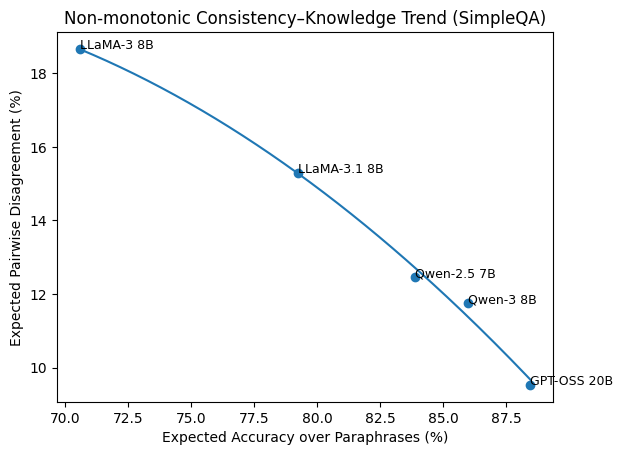

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# x, y from plot1 above
x = plot1["para_acc_pct"].values
y = plot1[y_col].values

plt.figure()
plt.scatter(x, y)
for _, r in plot1.iterrows():
    plt.text(r["para_acc_pct"], r[y_col], r["model"], fontsize=9)

# Quadratic fit: y ≈ ax^2 + bx + c
# NOTE: with only ~7 points, this is illustrative, not a strong statistical claim.
coef = np.polyfit(x, y, deg=2)
xx = np.linspace(x.min(), x.max(), 200)
yy = np.polyval(coef, xx)
plt.plot(xx, yy)

plt.xlabel("Expected Accuracy over Paraphrases (%)")
plt.ylabel(y_label)
plt.title("Non-monotonic Consistency–Knowledge Trend (SimpleQA)")
plt.show()


/tmp/ipykernel_867488/2112070416.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  curve = df_q.groupby("acc_bin")[y_qcol].mean().reset_index()


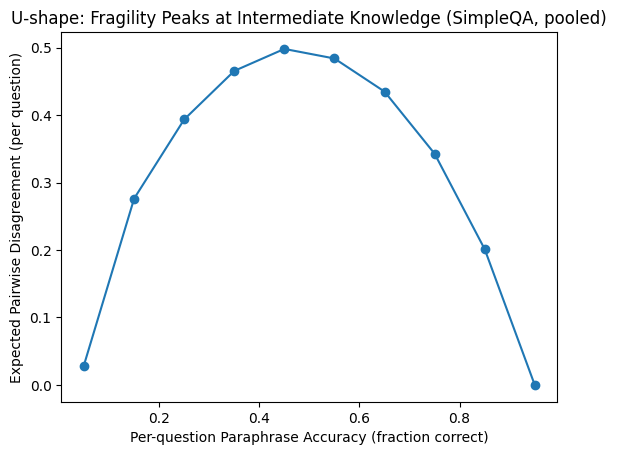

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For each question (row), we need:
# x_i: correctness fraction over paraphrases (0..1)
# y_i: instability for that question (entropy or pairwise mismatch prob)
# aligned seems to have normalized_entropy, iid_mismatch_prob per row.

df_q = aligned.reset_index()[["model", "correct_para", "iid_mismatch_prob_correct_para", "normalized_entropy_correct_para"]].copy()

# Choose which y to use
y_qcol = "iid_mismatch_prob_correct_para"
y_qlabel = "Expected Pairwise Disagreement (per question)"

# Bin x into deciles
bins = np.linspace(0, 1, 11)
df_q["acc_bin"] = pd.cut(df_q["correct_para"].astype(float), bins=bins, include_lowest=True)

# Aggregate within bins (option 1: across all models)
curve = df_q.groupby("acc_bin")[y_qcol].mean().reset_index()
curve["bin_center"] = curve["acc_bin"].apply(lambda x: (x.left + x.right) / 2)

plt.figure()
plt.plot(curve["bin_center"], curve[y_qcol], marker="o")
plt.xlabel("Per-question Paraphrase Accuracy (fraction correct)")
plt.ylabel(y_qlabel)
plt.title("U-shape: Fragility Peaks at Intermediate Knowledge (SimpleQA, pooled)")
plt.show()


/tmp/ipykernel_867488/3948991490.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub.groupby("acc_bin")[y_qcol]
/tmp/ipykernel_867488/3948991490.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub.groupby("acc_bin")[y_qcol]
/tmp/ipykernel_867488/3948991490.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub.groupby("acc_bin")[y_qcol]
/tmp/ipykernel_867488/3948991490.py:27: FutureWarning: The default of obs

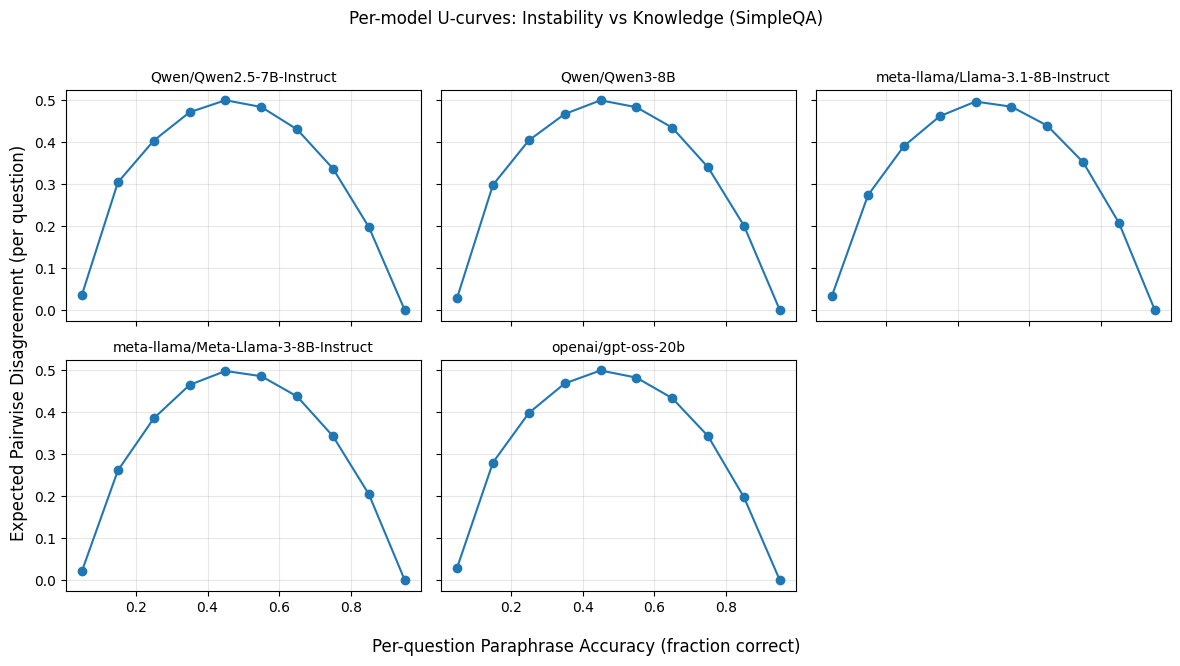

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

df_q = aligned.reset_index()[["model", "correct_para", "iid_mismatch_prob_correct_para", "normalized_entropy_correct_para"]].copy()

y_qcol = "iid_mismatch_prob_correct_para"
y_qlabel = "Expected Pairwise Disagreement (per question)"

bins = np.linspace(0, 1, 11)
df_q["acc_bin"] = pd.cut(df_q["correct_para"].astype(float), bins=bins, include_lowest=True)

models = sorted(df_q["model"].unique())

n = len(models)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.2*nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for ax, m in zip(axes, models):
    sub = df_q[df_q["model"] == m]

    curve = (
        sub.groupby("acc_bin")[y_qcol]
           .mean()
           .reset_index()
    )
    curve["bin_center"] = curve["acc_bin"].apply(lambda x: (x.left + x.right) / 2)

    ax.plot(curve["bin_center"], curve[y_qcol], marker="o")
    ax.set_title(m, fontsize=10)
    ax.grid(True, alpha=0.3)

# Hide unused axes
for j in range(len(models), len(axes)):
    axes[j].axis("off")

fig.supxlabel("Per-question Paraphrase Accuracy (fraction correct)")
fig.supylabel(y_qlabel)
fig.suptitle("Per-model U-curves: Instability vs Knowledge (SimpleQA)", y=1.02)
plt.tight_layout()
plt.show()


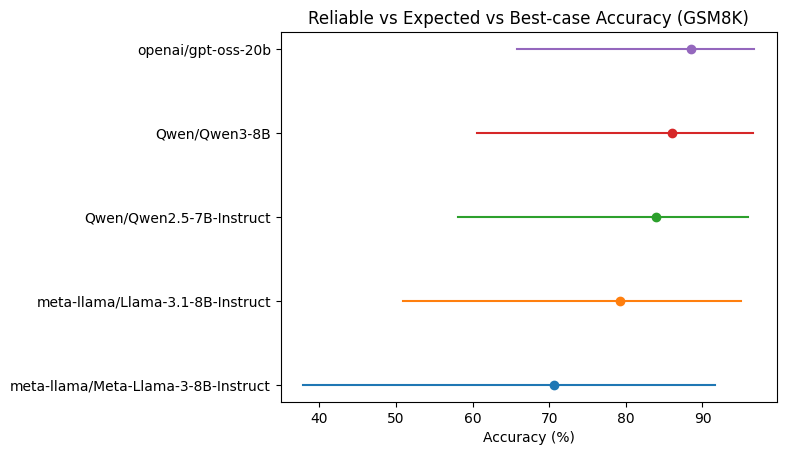

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# df_Aany has:
# Orig_Acc, Para_Acc, A_any_all, reliable_A (all already in %)

plot3 = df_Aany.copy()
plot3 = plot3.sort_values("Orig_Acc", ascending=True)  # nicer for horizontal plotting

models = plot3["model"].tolist()
y = np.arange(len(models))

reliable = plot3["reliable_A"].values
expected = plot3["Para_Acc"].values
bestcase = plot3["A_any_all"].values

plt.figure()
# Draw horizontal intervals from reliable -> bestcase
for i in range(len(models)):
    plt.plot([reliable[i], bestcase[i]], [y[i], y[i]])
    plt.scatter([expected[i]], [y[i]])  # dot at expected

plt.yticks(y, models)
plt.xlabel("Accuracy (%)")
plt.title("Reliable vs Expected vs Best-case Accuracy (GSM8K)")
plt.show()
